In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tqdm

import torch
from torch import nn

from torch.utils.data import DataLoader
import torchsummary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
baseline = pd.DataFrame({
    'RMSE': [3.060, 1.353, 1.371, 0.588, 0.374, 0.186, 0.182],
    'MAE': [1.534, 0.594, 0.724, 0.270, 0.160, 0.079, 0.088],
    'R2': [0.914, 0.935, 0.951, 0.913, 0.921, 0.917, 0.914],
    'delta': [0.440, 0.164, 0.166, 0.414, 0.315, 0.159, 0.182],
    'cumulative': [4.426, 1.751, 2.022, 0.649, 0.447, 0.222, 0.20]
}, index=['height', 'agb', 'soil', 'lai', 'gpp', 'npp', 'rh'])

In [3]:
DATA_DIR = "../data"
GLOB_DIR = DATA_DIR + '/data_global'
STAT_DIR = DATA_DIR + '/data_stats'

TREE_BAND = ['height', 'agb', 'soil', 'lai', 'gpp', 'npp', 'rh']
AGES = [1, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500]
N_SITE, N_YEAR, N_MONTH, N_FEA, N_OUT = 54152, 40, 12, 136, 7

print('Data dir :', DATA_DIR)
print('Targets  :', TREE_BAND)
print('Seed ages:', AGES)

mask2d = np.load(STAT_DIR + '/mask2d.npy')                # (360, 720), coordinates of land pixels

# Naive evolution of targets with age, based on the mean and slope of each target across age and location.
age_triplet = np.load(STAT_DIR + '/age_triplet.npz')            # (15,), (15,), (15,)
TRI_AGE, TRI_MEAN, TRI_SLOPE = age_triplet['age'], age_triplet['age_mean'], age_triplet['age_slope']

Data dir : ../data
Targets  : ['height', 'agb', 'soil', 'lai', 'gpp', 'npp', 'rh']
Seed ages: [1, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500]


In [4]:
stats = np.load(STAT_DIR + '/data_stats.npz')
x_mean, x_std = stats['x_mean'], stats['x_std'] # stats for normalization of the input variables (features, 136) 
y_mean, y_std = stats['y_mean'], stats['y_std']  # stats for normalization of the output variables (targets, 7)

def normalize_x(x, x_mean=x_mean, x_std=x_std):
    return (x - x_mean) / (x_std + 1e-10)

def inv_x(x, x_mean=x_mean, x_std=x_std):
    return x * (x_std + 1e-10) + x_mean


train_sample = np.load(GLOB_DIR + '/res_train4_test8.npz')
x_train, y_train, x_test, y_test = train_sample['x_train'], train_sample['y_train'], train_sample['x_test'], train_sample['y_test']

y_train = y_train.transpose(1, 0, 2, 3, 4)  # Transpose y_train so that site comes first
y_test = y_test.transpose(1, 0, 2, 3, 4)  # Transpose y_test so that site comes first

x_train, y_train = normalize_x(x_train), normalize_x(y_train, y_mean, y_std)
x_test, y_test = normalize_x(x_test), normalize_x(y_test, y_mean, y_std)


In [5]:
def prep_year(x, y, year, target_month = 12):
    """
    Prepare the input data for a specific year.
    Args:
        x: Input features (N_SITE, N_YEAR, N_MONTH, N_FEA)
        y: Output targets (MODEL_AGE, N_SITE, N_YEAR, N_MONTH, N_OUT)
        year: The year to prepare (0-indexed)
        month: Month to look at (default is 12, comparing december to december)
        norm: Whether to normalize the data (default is True)
    Returns:
        x_year: Input features for the specified year (N_SITE, N_FEA)
        y_year_prev: Output targets for the previous year (MODEL_AGE, N_SITE, N_OUT)
    """
    x_year = x[:, year, :, :]  # (N_SITE, N_FEA), annual mean over the 12 months

    # y intentionally stays December-only: this matches the tutorial/paper's convention of using
    # Grab the december of the previous year, as it is used as an additional input feature for the next year's prediction. 
    y_year_prev = y[:, :, year-1, target_month-1, :]  # (MODEL_AGE, N_SITE, N_OUT)
    return x_year, y_year_prev

input_size = x_train.shape[-1] + 8  # 136 features + 1 for age + previous 7 targets
n_classes = y_train.shape[-1]  # 7 targets

In [47]:
class MonthModel(nn.Module):
    def __init__(self, input_size, n_classes, hidden_size=128):
        super(MonthModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, n_classes)
        self.activation = nn.ReLU()
        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.25)
        self.output_activation = nn.Softmax(dim=-1)  # Assuming classification task; change to nn.Identity() for regression

    def forward(self, x):
        """
        Inputs:
        x: (Batch, N_site, N_fea) or (Batch, N_fea) - Month is chosen by the meta model
        
        Outputs:
        y: (Batch, N_site, N_out) or (Batch, N_out)
        """

        reshape_bool = False
        if x.dim() == 3:
            batch_size, n_site, n_fea = x.size()
            x = x.view(-1, n_fea)  # Flatten to (Batch * N_site, N_fea)
            reshape_bool = True
            
        x = self.dropout(x)
        x = self.activation(self.fc1(x))
        x = self.batch_norm1(x)
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.batch_norm1(x)
        y = self.fc3(x)
    
        if reshape_bool:
            y = y.view(batch_size, n_site, -1)  # Reshape back to (Batch, N_site, N_out)

        return self.output_activation(y)  # Apply output activation (Softmax for classification, Identity for regression)

class MonthMetaModel(nn.Module):
    def __init__(self, input_size, n_months, monthly_features, n_classes, hidden_size=128):
        super(MonthMetaModel, self).__init__()
        self.month_models = nn.ModuleList([MonthModel(input_size, monthly_features, hidden_size) for _ in range(n_months)])
        self.n_months = n_months
        self.meta_batchnorm1 = nn.BatchNorm1d(hidden_size)
        self.fc1_meta = nn.Linear(monthly_features* n_months, hidden_size)  # Meta model to select the month
        self.fc2_meta = nn.Linear(hidden_size, hidden_size)
        self.fc3_meta = nn.Linear(hidden_size, n_classes)
        self.activation = nn.ReLU()
        self.hidden_size = hidden_size
   
    def forward(self, x):
        """
        Inputs:
        x: (N_site, ages, N_months, N_fea) - Input features for all months
        Outputs:
        feature_predictions: (N_site, ages, n_classes) - Predicted features for yearly target based on previous months
        """
        batch, age, month, fea = x.size()
        for month in range(self.n_months):
            month_input = x[:, :, month, :]  # (Batch, age, N_site, N_fea)
            month_output = self.month_models[month](month_input)  # (Batch, age, N_site, N_out)
            if month == 0:
                all_month_outputs = month_output.unsqueeze(2)  # (Batch, age, N_site, 1, N_out)
            else:
                all_month_outputs = torch.cat((all_month_outputs, month_output.unsqueeze(2)), dim=2)  # (Batch, age, N_site, month+1, N_out)
        # Meta model to give outputs based on the per-month features
        all_month_features = all_month_outputs.view(all_month_outputs.size(0), all_month_outputs.size(1), -1)  # (Batch, age, N_months * N_out)
    
        meta_output = self.activation(self.fc1_meta(all_month_features))  # (Batch, age, hidden_size)
        meta_output = self.activation(self.fc2_meta(meta_output))  # (Batch, age, hidden_size)
        feature_predictions = self.fc3_meta(meta_output)  # (Batch, age, n_classes)
        return feature_predictions


input_size = x_train.shape[-1] + 8  # 136 features + 1 for age + previous 7 targets
n_classes = y_train.shape[-1]  # 7 targets
N_MONTH = 12
N_FEA = 8 # Per-month score vector  

META_MODEL = MonthMetaModel(
    input_size=input_size,
    n_months=N_MONTH,
    monthly_features=N_FEA,
    n_classes=n_classes
).to(device)

# Use fewer sites for the summary to avoid excessive memory usage.
torchsummary.summary(
    META_MODEL,
    (15, N_MONTH, input_size),  # Use a smaller batch size for the summary
    device=str(device),
)



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Dropout-1                  [-1, 144]               0
            Linear-2                  [-1, 128]          18,560
              ReLU-3                  [-1, 128]               0
       BatchNorm1d-4                  [-1, 128]             256
           Dropout-5                  [-1, 128]               0
            Linear-6                  [-1, 128]          16,512
              ReLU-7                  [-1, 128]               0
       BatchNorm1d-8                  [-1, 128]             256
            Linear-9                    [-1, 8]           1,032
          Softmax-10                [-1, 15, 8]               0
       MonthModel-11                [-1, 15, 8]               0
          Dropout-12                  [-1, 144]               0
           Linear-13                  [-1, 128]          18,560
             ReLU-14                  [

In [48]:
def prep_inputs_and_targets(x, y, year, pred_targets = None):
    """
    Prepare the input data and targets for a specific year.
    Args:
        x: Input features (N_SITE, N_YEAR, N_MONTH, N_FEA)
        y: Output targets (MODEL_AGE, N_SITE, N_YEAR, N_MONTH, N_OUT)
        year: The year to prepare (0-indexed)
    Returns:
        inputs: The prepared input data
        targets: The prepared target data
    """
    if year < 0 or year >= x.shape[1]:
        raise ValueError(f"Year {year} is out of bounds for the input data with shape {x.shape}")

    inputs, prev_targets = prep_year(x, y, year)
    targets = prep_year(x, y, year + 1)[1]  # Get targets for the next year
    # FIX: this was left as a numpy array while `inputs`/`prev_targets` were converted to tensors
    # below -- mse_loss(predictions, targets) then called `.size()` on a numpy array, where
    # `.size` is an int attribute rather than a method, raising `TypeError: 'int' object is not
    # callable`.
    targets = torch.as_tensor(targets, dtype=torch.float32, device=device)  # (MODEL_AGE, N_SITE, N_OUT)

    inputs = torch.as_tensor(inputs, dtype=torch.float32, device=device)  # (N_SITE, N_MONTH, N_FEA)
    inputs = inputs.unsqueeze(1).expand(-1, len(AGES), -1, -1)  # (N_SITE, MODEL_AGES, N_MONTH, N_FEA)

    if pred_targets is not None:
        prev_targets = pred_targets  # Use the model's own predictions for the next year's input

    prev_targets = torch.as_tensor(prev_targets, dtype=torch.float32, device=device)  # (N_SITE, MODEL_AGE,  N_OUT)
    prev_targets = prev_targets.unsqueeze(2).expand(-1, -1, N_MONTH, -1)  # (N_SITE, MODEL_AGE, N_MONTH, N_OUT)

    AGES_tensor = torch.tensor(np.array(AGES)/np.max(AGES), dtype=torch.float32, device=device).view(1, len(AGES), 1, 1)  # (1, MODEL_AGES, 1, 1)
    AGES_tensor = AGES_tensor.expand(inputs.size(0), -1, inputs.size(2), -1)  # (N_SITE, MODEL_AGES, N_MONTH, 1)

    inputs = torch.cat([inputs, prev_targets, AGES_tensor], dim=-1)  # (N_SITE, MODEL_AGES, N_MONTH, N_FEA + N_OUT + 1)
    return inputs, targets

year = 0  # Example year to prepare
test_in, test_targets = prep_inputs_and_targets(x_test, y_test, year)

test_pred = META_MODEL(test_in[:8])  # Use a smaller batch for testing
test_targets = test_targets[:8]  # Corresponding targets for the smaller batch

In [ ]:
optimizer = torch.optim.Adam(META_MODEL.parameters(), lr=0.001)
loss_func = nn.MSELoss()

train_on_own_output = False  # Set to True to train on the model's own output for the next year's prediction

epochs = 10
batch_size = 2048
month = 12
start_year, end_year = 0, 39
epoch_loss_list = []
val_loss_list = []

weights_list = []

for epoch in range(epochs):
    META_MODEL.train()


    epoch_loss = 0.0

    val_loss = 0.0
    META_MODEL.train()
    predictions_list = []
    for year in tqdm.tqdm(range(start_year, end_year)):
        
        inputs, targets = prep_inputs_and_targets(x_train, y_train, year)
        if train_on_own_output and year > start_year:
            # Use the model's own predictions from the previous year as input for the next year's prediction
        
            # Reshape predictions to match the expected input shape for the next year
            predictions_merged = torch.cat(predictions_list, dim=0)  # Concatenate predictions from all batches



            inputs, targets = prep_inputs_and_targets(x_train, y_train, year, pred_targets=predictions_merged.cpu().detach().numpy())
            predictions_list = []

        if inputs.size(0) < batch_size:
            current_batch_size = inputs.size(0)
        else:
            current_batch_size = batch_size
        N_batches = inputs.size(0) // current_batch_size
        for batch_idx in range(N_batches+1):
            batch_inputs = inputs[batch_idx * current_batch_size:(batch_idx + 1) * current_batch_size]
            batch_targets = targets[batch_idx * current_batch_size:(batch_idx + 1) * current_batch_size]
            if batch_inputs.size(0) == 0:
                continue  # Skip empty batches
            optimizer.zero_grad()
            predictions = META_MODEL(batch_inputs)
            # Use PyTorch's functional loss directly in case loss_func was
            # overwritten elsewhere in the notebook.
            loss_value = nn.functional.mse_loss(
                predictions,
                batch_targets
            )
            loss_value.backward()
            optimizer.step()
            predictions_list.append(predictions)
            epoch_loss += loss_value.item()

    epoch_loss_list.append(epoch_loss / (end_year - start_year) * current_batch_size)

    META_MODEL.eval()#

    predictions_list = []
    for year in tqdm.tqdm(range(start_year, end_year)):


        val_inputs, val_targets = prep_inputs_and_targets(x_test, y_test, year)
        if val_inputs.size(0) < batch_size:
            current_batch_size = val_inputs.size(0)
        else:
            current_batch_size = batch_size

        if train_on_own_output and year > start_year:
            # Use the model's own predictions from the previous year as input for the next year's prediction
            predictions_merged = torch.cat(predictions_list, dim=0)  # Concatenate predictions from all batches
            val_inputs, val_targets = prep_inputs_and_targets(x_test, y_test, year, pred_targets=predictions_merged.cpu().detach().numpy())
            predictions_list = []
        N_batches_val = val_inputs.size(0) // current_batch_size
        
        for batch_idx in range(N_batches_val+1):
            batch_inputs = val_inputs[batch_idx * current_batch_size:(batch_idx + 1) * current_batch_size]
            batch_targets = val_targets[batch_idx * current_batch_size:(batch_idx + 1) * current_batch_size]
            if batch_inputs.size(0) == 0:
                continue  # Skip empty batches
            with torch.no_grad():
                predictions = META_MODEL(batch_inputs)
                predictions_list.append(predictions)
    
                loss_value = nn.functional.mse_loss(
                    predictions,
                    batch_targets
                )
                val_loss += loss_value.item()

    
    val_loss_list.append(val_loss / (end_year - start_year) * current_batch_size)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss_list[-1]:.4f}, Val Loss: {val_loss_list[-1]:.4f}")
    weights_list.append(META_MODEL.state_dict())  # Save the model weights for this epoch

100%|██████████| 39/39 [00:00<00:00, 72.58it/s]


Epoch 1/10, Loss: 1783.3982, Val Loss: 135.0244


100%|██████████| 39/39 [00:00<00:00, 73.26it/s]


Epoch 2/10, Loss: 410.3637, Val Loss: 91.5574


100%|██████████| 39/39 [00:00<00:00, 72.92it/s]


...

Epoch 8/10, Loss: 201.5891, Val Loss: 86.9166


100%|██████████| 39/39 [00:00<00:00, 74.63it/s]


Epoch 9/10, Loss: 195.6513, Val Loss: 89.0828


100%|██████████| 39/39 [00:00<00:00, 72.96it/s]

Epoch 10/10, Loss: 190.7369, Val Loss: 88.2919


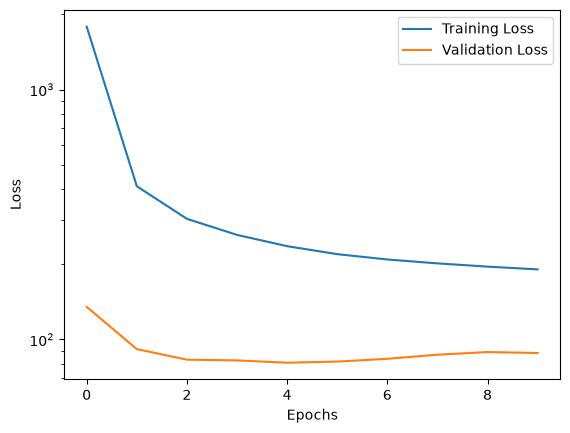

Minimum validation loss of 80.7595 occurred at epoch 5
Loaded model weights from epoch 5 with minimum validation loss.


In [50]:
plt.plot(epoch_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')  # Use logarithmic scale for better visibility
plt.legend()
plt.show()

min_val_loss_epoch = np.argmin(val_loss_list)
print(f"Minimum validation loss of {val_loss_list[min_val_loss_epoch]:.4f} occurred at epoch {min_val_loss_epoch + 1}")
META_MODEL.load_state_dict(weights_list[min_val_loss_epoch])  # Load the best model weights
print(f"Loaded model weights from epoch {min_val_loss_epoch + 1} with minimum validation loss.")

## Global test-set evaluation

Mirrors `tutorials/01_data_tutorial.ipynb` §6: a **40-year autoregressive rollout** (only the
year-0 init state `y0` is given; every later step consumes the model's *own* prior prediction as
`v`), scored with the tutorial's RMSE / MAE / R² plus the paper's **delta** (year-over-year change)
and **cumulative** (final-year) errors.

The difference from the training-loop cells above: this runs against the **full global grid**
(`glob_X_fea.npy` / `glob_Y{age}.npy`, sliced by `test.csv`'s 50,779 held-out sites), not just the
852-site `test8` subset baked into `res_train4_test8.npz` — i.e. the §1-② global-scale view from
`DATASET_NOTES.md`, which the tutorial only demonstrates for a single seed age on a per-site error
map, not as a pooled metrics table across all ages.


In [51]:
# --- Load site-split CSVs and memory-map the full-resolution global arrays ---
# glob_X_fea.npy / glob_Y{age}.npy are ~14GB each, so mmap_mode='r' keeps them on disk and only
# pulls the rows we index (train.csv/val.csv/test.csv are disjoint, so no test site ever leaks
# into training -- see DATASET_NOTES.md §6).

train_idx = pd.read_csv(DATA_DIR + '/train.csv', header=None)[0].values
val_idx   = pd.read_csv(DATA_DIR + '/val.csv',   header=None)[0].values
test_idx  = pd.read_csv(DATA_DIR + '/test.csv',  header=None)[0].values
print(f'train/val/test sites: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}')

glob_X = np.load(GLOB_DIR + '/glob_X_fea.npy', mmap_mode='r')  # (54152, 40, 12, 136)

def load_glob_Y(age):
    """Memory-mapped loader for one seed age's global output array, (54152, 41, 12, 7)."""
    return np.load(GLOB_DIR + f'/glob_Y{age:03d}.npy', mmap_mode='r')


train/val/test sites: 3035 / 338 / 50779


In [52]:
def global_arrays_monthly(site_idx, ages=AGES):
    """
    Fetch (X_month_n, Ydec_by_age) for a set of global-grid site indices -- the monthly-resolution
    analogue of the tutorial's `global_arrays` (which annual-averages for the RF baseline).

    Returns:
        X_month_n:   (S, N_YEAR, N_MONTH, N_FEA) normalized monthly inputs.
        Ydec_by_age: (len(ages), S, N_YEAR+1, N_OUT) PHYSICAL December targets, year 0 = init state.
    """
    site_idx = np.asarray(site_idx)
    X_month = np.asarray(glob_X[site_idx])                      # (S, 40, 12, 136) physical
    X_month_n = normalize_x(X_month).astype(np.float32)
    Ydec_by_age = np.stack([
        np.asarray(load_glob_Y(a)[site_idx][:, :, 11, :]) for a in ages
    ]).astype(np.float32)                                        # (A, S, 41, 7) physical
    return X_month_n, Ydec_by_age


@torch.no_grad()
def rollout_meta_model(model, X_month_n, Ydec_by_age, ages=AGES, site_batch=512, device=device):
    """
    Autoregressive 40-year rollout for MonthMetaModel, given ONLY the year-0 init state y0 --
    mirrors the tutorial's `rollout_rf` protocol (each prediction is fed back as the next year's
    `v`), so results are comparable to the RF/DeepED/Transformer baselines and to the paper's
    reported numbers.

    X_month_n:   (S, N_YEAR, N_MONTH, N_FEA) normalized monthly inputs (from `global_arrays_monthly`).
    Ydec_by_age: (A, S, N_YEAR+1, N_OUT) PHYSICAL December targets, year 0 = init state.

    Returns (pred, true), each (A, S, N_YEAR, N_OUT) in PHYSICAL units.
    """
    model.eval()
    A, S = len(ages), X_month_n.shape[0]
    age_scaled = torch.tensor(np.asarray(ages) / np.max(AGES), dtype=torch.float32, device=device)  # (A,)

    pred = np.empty((A, S, N_YEAR, N_OUT), dtype=np.float32)
    true = Ydec_by_age[:, :, 1:, :]  # (A, S, N_YEAR, N_OUT) physical, years 1..40

    for start in range(0, S, site_batch):
        end = min(start + site_batch, S)
        bs = end - start

        x_batch = torch.as_tensor(X_month_n[start:end], dtype=torch.float32, device=device)     # (bs, 40, 12, 136)
        y0_n = normalize_x(Ydec_by_age[:, start:end, 0, :], y_mean, y_std).astype(np.float32)    # (A, bs, 7)
        v = torch.as_tensor(y0_n, dtype=torch.float32, device=device).permute(1, 0, 2)           # (bs, A, 7) init v

        age_col = age_scaled.view(1, A, 1).expand(bs, -1, -1)                                    # (bs, A, 1)

        for t in range(N_YEAR):
            x_year = x_batch[:, t, :, :].unsqueeze(1).expand(-1, A, -1, -1)          # (bs, A, 12, 136)
            v_month = v.unsqueeze(2).expand(-1, -1, N_MONTH, -1)                     # (bs, A, 12, 7)
            age_month = age_col.unsqueeze(2).expand(-1, -1, N_MONTH, -1)             # (bs, A, 12, 1)
            model_in = torch.cat([x_year, v_month, age_month], dim=-1)               # (bs, A, 12, N_FEA+8)

            pred_n = model(model_in)                                                 # (bs, A, 7) normalized
            pred_phys = inv_x(pred_n.cpu().numpy(), y_mean, y_std)                    # (bs, A, 7) physical
            pred[:, start:end, t, :] = pred_phys.transpose(1, 0, 2)

            v = pred_n  # feed the model's own prediction forward as next year's v -- errors accumulate

    return pred, true


def metrics_table_global(true_seq, pred_seq, target_names=TREE_BAND):
    """
    true_seq, pred_seq: (A, S, N_YEAR, N_OUT) physical-unit arrays from `rollout_meta_model`.
    Mirrors the tutorial's `metrics_table`: RMSE/MAE/R2 pooled over (age, site, year), plus the
    paper's delta (year-over-year change) and cumulative (final-year) errors.
    """
    t = true_seq.reshape(-1, true_seq.shape[-1])
    p = pred_seq.reshape(-1, pred_seq.shape[-1])
    rmse = np.sqrt(np.mean((t - p) ** 2, axis=0))
    mae = np.mean(np.abs(t - p), axis=0)
    ss_res = np.sum((t - p) ** 2, axis=0)
    ss_tot = np.sum((t - t.mean(0)) ** 2, axis=0)
    r2 = 1 - ss_res / ss_tot
    dt = np.diff(true_seq, axis=2); dp = np.diff(pred_seq, axis=2)
    delta = np.sqrt(np.mean((dt - dp) ** 2, axis=(0, 1, 2)))
    ce = np.sqrt(np.mean((true_seq[:, :, -1, :] - pred_seq[:, :, -1, :]) ** 2, axis=(0, 1)))
    return pd.DataFrame({'RMSE': rmse, 'MAE': mae, 'R2': r2, 'delta': delta, 'cumulative': ce},
                         index=target_names).round(3)

In [53]:
# Evaluate on the full global test set (test.csv, 50,779 sites) x all 15 seed ages -- this is the
# §1-② global-scale view, not just the 852-site test8 subset the training-loop cells above use.
# Full 50,779 x 15 x 40-year rollout is a lot of forward passes; start with a random subsample to
# sanity-check the pipeline, then set n_eval_sites=None for the full run.
n_eval_sites = 2000  # set to None to evaluate all 50,779 test.csv sites
eval_idx = test_idx if n_eval_sites is None else np.random.RandomState(0).choice(test_idx, n_eval_sites, replace=False)

X_eval_n, Ydec_eval = global_arrays_monthly(eval_idx, ages=AGES)
print(f'Autoregressive rollout on {len(eval_idx)} global test sites x {len(AGES)} ages (y0 given only)...')
pred_seq, true_seq = rollout_meta_model(META_MODEL, X_eval_n, Ydec_eval, ages=AGES)

global_metrics = metrics_table_global(true_seq, pred_seq)
print('MonthMetaModel -- 40-yr autoregressive rollout on the global test set (physical units):')
global_metrics

Autoregressive rollout on 2000 global test sites x 15 ages (y0 given only)...
MonthMetaModel -- 40-yr autoregressive rollout on the global test set (physical units):


,RMSE,MAE,R2,delta,cumulative
height,6.449,4.446,0.624,0.645,6.785
agb,4.102,2.275,0.420,0.294,3.970
soil,4.867,3.424,0.386,0.365,4.953
lai,1.261,0.825,0.621,0.376,1.221
gpp,0.758,0.403,0.700,0.322,0.723
npp,0.375,0.197,0.687,0.162,0.357
rh,0.364,0.186,0.663,0.190,0.356


In [54]:
global_metrics / baseline

,RMSE,MAE,R2,delta,cumulative
height,2.107516,2.898305,0.682713,1.465909,1.532987
agb,3.031781,3.829966,0.449198,1.792683,2.267276
soil,3.549964,4.729282,0.405889,2.198795,2.449555
lai,2.144558,3.055556,0.680175,0.908213,1.881356
gpp,2.026738,2.518750,0.760043,1.022222,1.617450
npp,2.016129,2.493671,0.749182,1.018868,1.608108
rh,2.000000,2.113636,0.725383,1.043956,1.780000


## Teacher/student recursive wrapper (model-agnostic)

Per `DATASET_NOTES.md` §11: teacher forcing (train on the *true* previous-year `v`) is easy to
optimize but creates exposure bias, since the model never practices recovering from its own
mistakes before being asked to do exactly that at test time via a 40-year autoregressive rollout.
The class below implements the proposed teacher/student bridge:

- **Teacher path** — at every year, `v` is the TRUE previous year's target (teacher forcing).
  Solves a well-posed one-step regression problem per year, so it converges quickly and stably.
- **Student path** — only the true year-0 state is given; every subsequent year's `v` is the
  model's *own* prior prediction (full autoregressive rollout), exactly matching test-time
  conditions.
- An auxiliary **distillation loss** pulls the student's per-step prediction toward the teacher's
  (stop-gradient) prediction for the same year, giving the student extra stable gradient signal on
  top of its own harder rollout loss.

The wrapper is deliberately **agnostic to the core model's architecture** — it only requires an
`nn.Module` whose `forward` maps a batch of per-year inputs
`(N_site, N_age, N_month, N_fea + N_out + 1)` — climate features concatenated with the previous
year's `v` and the scaled seed age, exactly `MonthMetaModel`'s current interface — to that year's
predicted `(N_site, N_age, N_out)` target vector. Any architecture matching that signature (the
`MonthMetaModel` above, a plain MLP, a transformer, ...) can be dropped in via `core_model` without
touching this class. By default teacher and student share one set of weights (`core_model` trained
jointly through both paths); pass a distinct `student_model` to use two separate networks instead
(e.g. warm-starting a student from an already-converged, frozen teacher — the other option
discussed in the notes).

In [56]:
class TeacherStudentRollout(nn.Module):
    """
    Model-agnostic teacher/student wrapper for the recursive year-by-year carbon-state forecast.

    Wraps an externally-defined "core" model -- any `nn.Module` whose `forward` maps a batch of
    per-year inputs `(N_site, N_age, N_month, N_fea + N_out + 1)` (climate features ++ previous
    year's target vector `v` ++ scaled seed age) to that year's predicted `(N_site, N_age, N_out)`
    targets, exactly `MonthMetaModel`'s existing signature -- and adds the teacher-forced /
    autoregressive rollout mechanics on top, without knowing anything about the core model's
    internals.

    - `teacher_rollout` feeds the TRUE previous year's `v` at every step (teacher forcing).
    - `student_rollout` feeds the model's OWN previous prediction at every step (full
      autoregressive rollout), seeded only by the true year-0 state -- matching test-time/
      deployment conditions.
    - `compute_losses` runs both and returns the supervised losses plus a distillation loss that
      pulls the student's per-step prediction toward the teacher's (stop-gradient) prediction for
      the same year.
    - `update_teacher` nudges the teacher's weights toward the student's by exponential moving
      average (the "mean teacher" pattern, Tarvainen & Valpola 2017) instead of ever copying the
      student onto the teacher outright -- the teacher is meant to become a slow, smoothed
      trajectory of the student's weights (which tends to generalize better than the raw student at
      any single step, similar to weight averaging/SWA), not to collapse into being the student.
      That smoothed teacher then keeps supervising the student via `distill_loss`, so the two can
      improve together rather than the teacher acting as a fixed ceiling.

    By default `student_model` is omitted and both paths share one set of weights (`core_model`),
    which are trained jointly through both losses. Pass a distinct `student_model` (e.g. a copy of
    an already-converged, frozen teacher) to decouple them -- see `DATASET_NOTES.md` §11's "warm
    start" alternative. When decoupled, the teacher rollout is run under `torch.no_grad()` since
    its output is only ever used detached (as the distillation target), saving the memory of a
    computation graph nobody will backprop through.
    """

    def __init__(self, core_model, student_model=None, ages=AGES, n_months=N_MONTH):
        super().__init__()
        self.teacher_model = core_model
        self.student_model = student_model if student_model is not None else core_model
        self.shares_weights = student_model is None

        self.ages = np.asarray(ages)
        self.n_months = n_months
        self.register_buffer(
            "age_scaled", torch.tensor(self.ages / self.ages.max(), dtype=torch.float32)
        )

    def _build_step_input(self, x_year, v):
        """
        x_year: (N_site, N_age, N_month, N_fea)
        v:      (N_site, N_age, N_out) -- the previous year's target state
        Returns (N_site, N_age, N_month, N_fea + N_out + 1)
        """
        n_site, n_age = x_year.shape[0], x_year.shape[1]
        age_col = self.age_scaled.to(x_year.device).view(1, n_age, 1).expand(n_site, -1, -1)  # (N_site, N_age, 1)
        v_month = v.unsqueeze(2).expand(-1, -1, self.n_months, -1)
        age_month = age_col.unsqueeze(2).expand(-1, -1, self.n_months, -1)
        return torch.cat([x_year, v_month, age_month], dim=-1)

    def rollout(self, model, x, y_true, start_year=0, end_year=N_YEAR, teacher_forcing=True):
        """
        Roll `model` forward year-by-year over [start_year, end_year).

        x:      (N_site, N_year, N_month, N_fea) inputs (whatever units/scale the model expects)
        y_true: (N_site, N_age, N_year+1, N_out) targets, year 0 = init state (same units as x's
                target space). Only `y_true[:, :, start_year, :]` (the init state) is required when
                `teacher_forcing=False` -- later years are read from `y_true` only to supply `v`
                when teacher forcing.

        Returns: predictions, shape (N_site, N_age, end_year - start_year, N_out)
        """
        v = y_true[:, :, start_year, :]
        preds = []
        for t in range(start_year, end_year):
            n_age = v.shape[1]
            x_year = x[:, t, :, :].unsqueeze(1).expand(-1, n_age, -1, -1)  # (N_site, N_age, N_month, N_fea)
            step_in = self._build_step_input(x_year, v)
            pred = model(step_in)  # (N_site, N_age, N_out)
            preds.append(pred)
            v = y_true[:, :, t + 1, :] if teacher_forcing else pred
        return torch.stack(preds, dim=2)  # (N_site, N_age, T, N_out)

    def teacher_rollout(self, x, y_true, start_year=0, end_year=N_YEAR):
        return self.rollout(self.teacher_model, x, y_true, start_year, end_year, teacher_forcing=True)

    def student_rollout(self, x, y_true, start_year=0, end_year=N_YEAR):
        return self.rollout(self.student_model, x, y_true, start_year, end_year, teacher_forcing=False)

    def compute_losses(self, x, y_true, start_year=0, end_year=N_YEAR, distill_weight=1.0):
        """
        Runs both rollouts and returns the loss components for one training step:
          - 'teacher_loss': teacher predictions vs true targets -- supervises the teacher path.
          - 'student_loss': student predictions vs true targets -- the actual objective (matches
            the autoregressive test-time protocol).
          - 'distill_loss': student predictions vs teacher predictions (stop-gradient) -- extra,
            stable gradient signal pulling the harder autoregressive rollout toward the teacher's.
          - 'total': student_loss + distill_weight * distill_loss, plus teacher_loss when the two
            paths share weights (so the shared core model is also directly supervised).
        """
        targets = y_true[:, :, start_year + 1:end_year + 1, :]  # (N_site, N_age, T, N_out)

        if self.shares_weights:
            teacher_pred = self.teacher_rollout(x, y_true, start_year, end_year)
        else:
            # Teacher is a separate, already-trained network here -- its output is only ever used
            # detached (as the distillation target), so skip building its autograd graph entirely.
            with torch.no_grad():
                teacher_pred = self.teacher_rollout(x, y_true, start_year, end_year)

        student_pred = self.student_rollout(x, y_true, start_year, end_year)

        teacher_loss = nn.functional.mse_loss(teacher_pred, targets)
        student_loss = nn.functional.mse_loss(student_pred, targets)
        distill_loss = nn.functional.mse_loss(student_pred, teacher_pred.detach())

        total = student_loss + distill_weight * distill_loss
        if self.shares_weights:
            total = total + teacher_loss

        return {
            "teacher_loss": teacher_loss,
            "student_loss": student_loss,
            "distill_loss": distill_loss,
            "total": total,
        }

    @torch.no_grad()
    def update_teacher(self, decay=0.999):
        """
        Exponential-moving-average update of the teacher's weights toward the student's:
            teacher <- decay * teacher + (1 - decay) * student
        the "mean teacher" pattern (Tarvainen & Valpola, 2017). `decay` close to 1 (e.g. 0.999)
        keeps the teacher slow-moving -- a smoothed trajectory of the student's weights rather than
        a copy of the student at any single step, which is why the teacher can end up *better* than
        a plain snapshot of the student (analogous to stochastic weight averaging). Call this once
        per optimizer step (after `student_optimizer.step()`), not once per epoch, so the teacher
        tracks the student's weight trajectory smoothly rather than in large jumps.

        Requires a distinct `student_model` -- meaningless (and refused) when the two paths share
        weights, since there the "teacher" and "student" are the same tensors already.
        """
        if self.shares_weights:
            raise RuntimeError(
                "update_teacher() requires a distinct student_model; teacher and student share "
                "weights here, so there is nothing separate to average toward."
            )
        for t_param, s_param in zip(self.teacher_model.parameters(), self.student_model.parameters()):
            t_param.mul_(decay).add_(s_param, alpha=1 - decay)
        for t_buf, s_buf in zip(self.teacher_model.buffers(), self.student_model.buffers()):
            if torch.is_floating_point(t_buf):
                t_buf.mul_(decay).add_(s_buf, alpha=1 - decay)
            else:
                t_buf.copy_(s_buf)  # e.g. BatchNorm's num_batches_tracked -- an integer count, not averaged


# --- Usage sketch (shared weights: one MonthMetaModel trained through both the teacher-forced and
# fully-autoregressive paths at once) ---

teacher_baseline = META_MODEL.state_dict()  # save a copy of the converged MonthMetaModel from above as a baseline
META_MODEL.load_state_dict(teacher_baseline)  # reset to the converged MonthMetaModel

ts_wrapper = TeacherStudentRollout(core_model=META_MODEL).to(device)
optimizer = torch.optim.Adam(ts_wrapper.parameters(), lr=0.001)

x_batch = torch.as_tensor(x_train[:64], dtype=torch.float32, device=device)                     # (N_site, N_year, N_month, N_fea)
y_batch = torch.as_tensor(y_train[:64, :, :, 11, :], dtype=torch.float32, device=device)        # December-only -> (N_site, MODEL_AGE, N_year+1, N_out)

optimizer.zero_grad()
losses = ts_wrapper.compute_losses(x_batch, y_batch, start_year=0, end_year=5)
losses["total"].backward()
optimizer.step()
{k: v.item() for k, v in losses.items()}

{'teacher_loss': 0.0245262049138546,
 'student_loss': 0.04281600937247276,
 'distill_loss': 0.004444811027497053,
 'total': 0.071787029504776}

### Student training loop (teacher pretrained, frozen)

Mirrors the epoch/batch structure of the teacher-forced training loop above (`optimizer`/`epochs`/
`batch_size` in cell `97de8784`), but for the student half of `TeacherStudentRollout`:

- **Teacher** = `META_MODEL` as already trained by the cell above (teacher-forced, one-step-ahead).
  Its weights are frozen here (`requires_grad_(False)`, `.eval()`) -- it is only used to produce
  the stop-gradient distillation target, not trained further.
- **Student** = a freshly-initialized `MonthMetaModel` with the same architecture, trained via
  `TeacherStudentRollout.compute_losses` -- full autoregressive rollout from the true year-0 state,
  supervised by both the true targets (`student_loss`) and the frozen teacher's one-step predictions
  for the same years (`distill_loss`).

A full 39-year rollout backpropagated in one shot is a long computation graph (39 sequential
forward passes per batch), so the loop below rolls in `bptt_years`-sized windows, re-anchoring `v`
to the true state at the start of each window (truncated BPTT) -- set `bptt_years = end_year -
start_year` for a single full-length rollout if memory allows.

In [57]:
# --- Teacher: assumed pretrained by the loop in cell 97de8784 above -- freeze it, use only for
# the distillation target. Its weights are no longer trained by gradient descent -- instead they
# drift slowly toward the student's via `update_teacher`'s EMA below ---
TEACHER_MODEL = META_MODEL
for p in TEACHER_MODEL.parameters():
    p.requires_grad_(False)
TEACHER_MODEL.eval()

# --- Student: a fresh network with the same architecture/hyperparameters, trained from scratch ---
STUDENT_MODEL = MonthMetaModel(
    input_size=input_size,
    n_months=N_MONTH,
    monthly_features=N_FEA,
    n_classes=n_classes
).to(device)

ts_wrapper = TeacherStudentRollout(core_model=TEACHER_MODEL, student_model=STUDENT_MODEL).to(device)
student_optimizer = torch.optim.Adam(ts_wrapper.student_model.parameters(), lr=0.001)

epochs = 25
site_batch_size = 1024   # sites per batch (each site expands to N_age=15 rows inside the wrapper)
start_year, end_year = 0, 39
bptt_years = 10          # truncated-BPTT window length -- re-anchors v to the true state each window
distill_weight = 1.0
teacher_ema_decay = 0.9999  # higher = teacher moves more slowly toward the student

y_train_dec = y_train[:, :, :, 11, :]  # December-only -> (N_site, MODEL_AGE, N_year+1, N_out)
y_test_dec = y_test[:, :, :, 11, :]

n_train_sites = x_train.shape[0]
n_val_sites = x_test.shape[0]

student_epoch_loss_list = []
student_val_loss_list = []
teacher_val_loss_list = []

student_weights_list = []  # to save the student model's weights after each epoch for later analysis

for epoch in range(epochs):
    ts_wrapper.student_model.train()
    TEACHER_MODEL.eval()

    epoch_loss, n_batches = 0.0, 0
    site_perm = np.random.permutation(n_train_sites)
    for b_start in tqdm.tqdm(range(0, n_train_sites, site_batch_size)):
        idx = site_perm[b_start:b_start + site_batch_size]
        x_batch = torch.as_tensor(x_train[idx], dtype=torch.float32, device=device)
        y_batch = torch.as_tensor(y_train_dec[idx], dtype=torch.float32, device=device)

        for w_start in range(start_year, end_year, bptt_years):
            w_end = min(w_start + bptt_years, end_year)

            student_optimizer.zero_grad()
            losses = ts_wrapper.compute_losses(
                x_batch, y_batch, start_year=w_start, end_year=w_end, distill_weight=distill_weight
            )
            losses["total"].backward()
            student_optimizer.step()
            # Slowly pull the teacher toward the student's just-updated weights -- an EMA, not a
            # copy, so the teacher keeps supervising the student rather than becoming it outright.
            ts_wrapper.update_teacher(decay=teacher_ema_decay)

            epoch_loss += losses["student_loss"].item()
            n_batches += 1

    student_epoch_loss_list.append(epoch_loss / n_batches)
    student_weights_list.append(ts_wrapper.student_model.state_dict())  # save the student model's weights after each epoch
    
    ts_wrapper.student_model.eval()
    TEACHER_MODEL.eval()
    val_loss, teacher_val_loss_sum, n_val_batches = 0.0, 0.0, 0
    with torch.no_grad():
        for b_start in range(0, n_val_sites, site_batch_size):
            x_batch = torch.as_tensor(x_test[b_start:b_start + site_batch_size], dtype=torch.float32, device=device)
            y_batch = torch.as_tensor(y_test_dec[b_start:b_start + site_batch_size], dtype=torch.float32, device=device)

            for w_start in range(start_year, end_year, bptt_years):
                w_end = min(w_start + bptt_years, end_year)
                losses = ts_wrapper.compute_losses(
                    x_batch, y_batch, start_year=w_start, end_year=w_end, distill_weight=distill_weight
                )
                val_loss += losses["student_loss"].item()
                teacher_val_loss_sum += losses["teacher_loss"].item()
                n_val_batches += 1

    student_val_loss_list.append(val_loss / n_val_batches)
    teacher_val_loss_list.append(teacher_val_loss_sum / n_val_batches)
    print(
        f"Epoch {epoch + 1}/{epochs}, Student Loss: {student_epoch_loss_list[-1]:.4f}, "
        f"Student Val Loss: {student_val_loss_list[-1]:.4f}, "
        f"Teacher (EMA) Val Loss: {teacher_val_loss_list[-1]:.4f}"
    )

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:09<00:00,  2.40s/it]


Epoch 1/25, Student Loss: 0.8411, Student Val Loss: 0.6534, Teacher (EMA) Val Loss: 0.1071


100%|██████████| 4/4 [00:09<00:00,  2.37s/it]


Epoch 2/25, Student Loss: 0.4694, Student Val Loss: 0.3682, Teacher (EMA) Val Loss: 0.1086


...

Epoch 17/25, Student Loss: 0.1094, Student Val Loss: 0.1821, Teacher (EMA) Val Loss: 0.1335


100%|██████████| 4/4 [00:09<00:00,  2.35s/it]


Epoch 18/25, Student Loss: 0.1084, Student Val Loss: 0.2137, Teacher (EMA) Val Loss: 0.1354


 50%|█████     | 2/4 [00:06<00:06,  3.42s/it]


KeyboardInterrupt: 

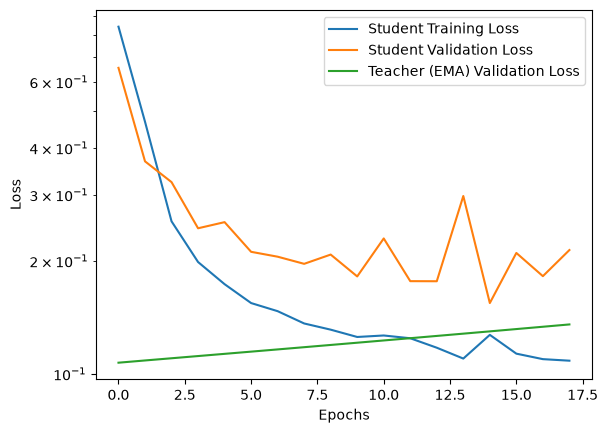

Minimum student validation loss of 0.1544 occurred at epoch 15


<All keys matched successfully>

In [58]:
plt.plot(student_epoch_loss_list, label='Student Training Loss')
plt.plot(student_val_loss_list, label='Student Validation Loss')
plt.plot(teacher_val_loss_list, label='Teacher (EMA) Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

min_student_val_loss_epoch = np.argmin(student_val_loss_list)
print(f"Minimum student validation loss of {student_val_loss_list[min_student_val_loss_epoch]:.4f} occurred at epoch {min_student_val_loss_epoch + 1}")
ts_wrapper.student_model.load_state_dict(student_weights_list[min_student_val_loss_epoch])  # Load the best student model

In [59]:
# Evaluate on the full global test set (test.csv, 50,779 sites) x all 15 seed ages -- this is the
# §1-② global-scale view, not just the 852-site test8 subset the training-loop cells above use.
# Full 50,779 x 15 x 40-year rollout is a lot of forward passes; start with a random subsample to
# sanity-check the pipeline, then set n_eval_sites=None for the full run.
n_eval_sites = 2000  # set to None to evaluate all 50,779 test.csv sites
eval_idx = test_idx if n_eval_sites is None else np.random.RandomState(0).choice(test_idx, n_eval_sites, replace=False)

X_eval_n, Ydec_eval = global_arrays_monthly(eval_idx, ages=AGES)
print(f'Autoregressive rollout on {len(eval_idx)} global test sites x {len(AGES)} ages (y0 given only)...')
pred_seq, true_seq = rollout_meta_model(STUDENT_MODEL, X_eval_n, Ydec_eval, ages=AGES)

global_metrics = metrics_table_global(true_seq, pred_seq)
print('MonthMetaModel -- 40-yr autoregressive rollout on the global test set (physical units):')
global_metrics/baseline

Autoregressive rollout on 2000 global test sites x 15 ages (y0 given only)...
MonthMetaModel -- 40-yr autoregressive rollout on the global test set (physical units):


,RMSE,MAE,R2,delta,cumulative
height,1.616340,2.356584,0.852298,1.665909,1.366471
agb,1.811530,2.584175,0.848128,1.567073,1.411765
soil,2.800875,3.758287,0.649842,2.072289,2.012364
lai,1.559524,2.411111,0.876232,0.862319,1.596302
gpp,1.470588,2.000000,0.914224,0.885714,1.351230
npp,1.467742,2.000000,0.909487,0.886792,1.355856
rh,1.417582,1.693182,0.909190,1.021978,1.410000


C:\Users\joebo\AppData\Local\Temp\ipykernel_10744\675853536.py:4: RuntimeWarning: divide by zero encountered in divide
  dev = (true_seq - pred_seq) / true_seq


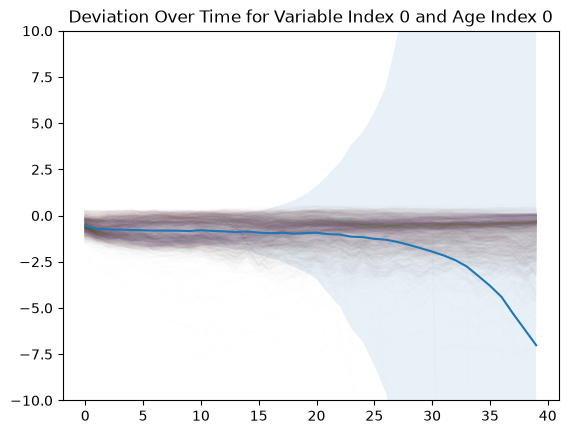

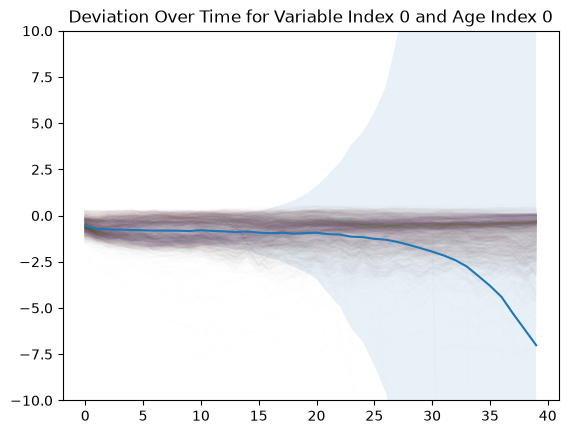

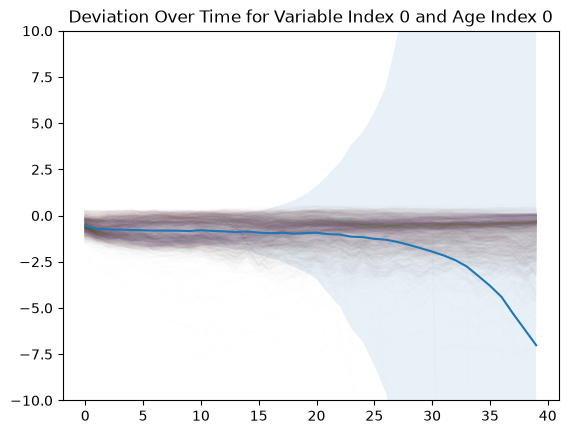

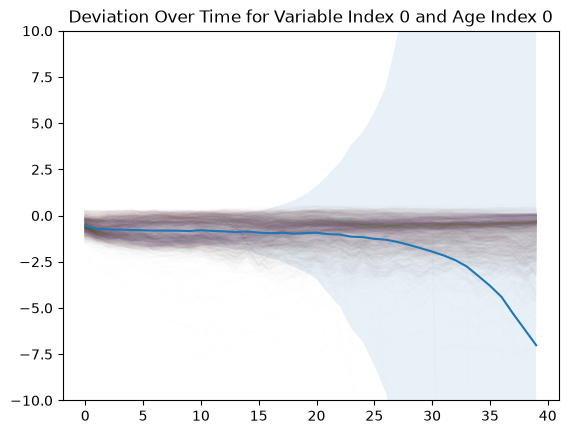

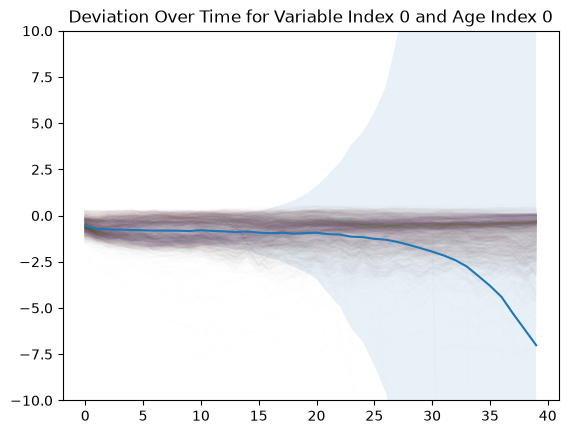

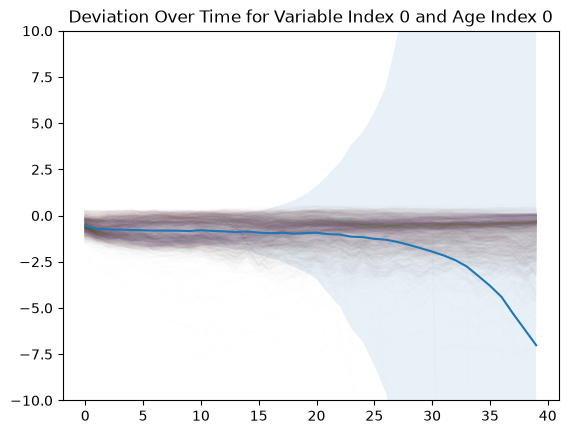

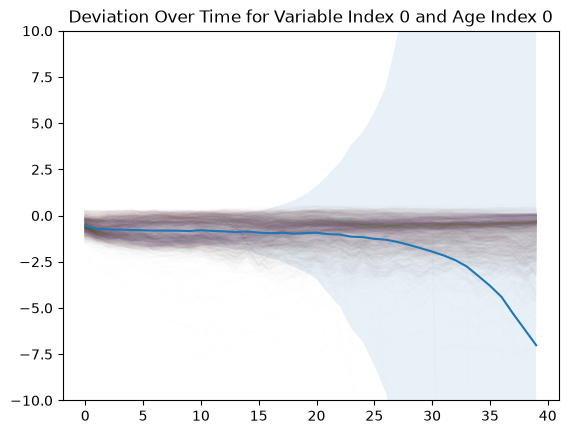

In [60]:
def deviation_over_time(true_seq, pred_seq, var_i=0, age=0):
    true_seq = true_seq[age, :, :, var_i]  # (S, N_YEAR)
    pred_seq = pred_seq[age, :, :, var_i]  # (S,
    dev = (true_seq - pred_seq) / true_seq
    dev = np.where(true_seq == 0, 0, dev)  # Handle division by zero
    return dev

for var_i in range(true_seq.shape[-1]):  # Loop over all variables
    var_i_dev = deviation_over_time(true_seq, pred_seq, var_i=0, age=0)  # Example for variable index 0 and age index 0

    #plt.plot(var_i_dev, alpha=0.01, color='gray')  # Plot individual site deviations with low opacity
    for site_idx in range(var_i_dev.shape[0]):
        plt.plot(var_i_dev[site_idx], alpha=0.005)  # Plot individual site deviations with low opacity
    var_i_dev_mean = np.mean(var_i_dev.T, axis=1)  # Mean deviation over sites for each year
    var_i_dev_std = np.std(var_i_dev.T, axis=1)    # Standard deviation over sites for each year

    plt.plot(var_i_dev_mean, label='Mean Deviation')
    plt.fill_between(range(len(var_i_dev_mean)), var_i_dev_mean - var_i_dev_std, var_i_dev_mean + var_i_dev_std, alpha=0.1, label='Std Dev')
    plt.ylim(-10,10)
    plt.title(f'Deviation Over Time for Variable Index {0} and Age Index {0}')
    plt.show()


# Submission

Kaggle scores only the **year-40 (final) state** of `height` and `agb`, for two future-climate
scenarios (`ssp126`, `ssp585`), each covering **6171 sites x 15 seed ages** -- see
`data/public/README.md`. This differs from the global evaluation above in a few ways:

- Inputs come from `data/public/test_{ssp126,ssp585}.npz` (`test_x`, `test_y0`), not the training
  arrays -- `test_y0` plays the same role as the historical `glob_Y{age}` December value did above
  (the year-0 init state), and both scenarios share one site index (`sites_ssp.csv`). Both arrays
  are in **physical units** (verified below), exactly like `glob_X_fea.npy`/`glob_Y{age}.npy`, so
  they go through the same `normalize_x`/`inv_x` round-trip as everywhere else in this notebook.
- Only the **final** year-40 state is needed (not the whole 40-year trajectory), so the rollout
  below keeps just the last step instead of storing every year like `rollout_meta_model` does above.
- The two submitted columns must each be divided by their **global mean** (`10.90645` for height,
  `3.39567` for agb -- exactly `y_mean[0]`/`y_mean[1]` from `data_stats.npz`) before writing
  `submission.csv`, per the competition's pre-scaled-MSE metric.
- `sample_submission.csv` fixes the exact row order: scenario (`ssp126` then `ssp585`), then site
  (in `sites_ssp.csv` order), then seed age (in `AGES` order) -- the code below builds rows in that
  same order and asserts against `sample_submission.csv` rather than trusting it silently.

Uses `STUDENT_MODEL` (trained via `TeacherStudentRollout` to roll out from only `y0`, exactly this
protocol) -- swap `SUBMISSION_MODEL` below for `META_MODEL`/`TEACHER_MODEL` to submit a different
run instead.


In [61]:
# Sanity-check the units assumption above before trusting it: test_x's per-channel mean should
# land near x_mean (physical), not near 0 (normalized); same idea for test_y0 vs y_mean.
_probe = np.load(DATA_DIR + '/public/test_ssp126.npz')
print('test_x  ch0 mean (expect ~x_mean[0]):', _probe['test_x'][..., 0].mean(), 'vs x_mean[0] =', x_mean[0])
print('test_y0 height mean, age=500 (expect ~y_mean[0] order):', _probe['test_y0'][:, -1, 0].mean(), 'vs y_mean[0] =', y_mean[0])
del _probe


@torch.no_grad()
def rollout_final_state(model, test_x, test_y0, ages=AGES, site_batch=512, device=device):
    """
    Autoregressive rollout for the Kaggle test set, given ONLY the year-0 state -- same protocol as
    `rollout_meta_model` above, but adapted to the submission files' axis order (site, age, out)
    and returning only the FINAL step, since that's all the leaderboard scores (`data/public/
    README.md`: "report the year-40 (final) state").

    test_x:  (S, N_YEAR, N_MONTH, N_FEA) PHYSICAL monthly inputs, e.g. `test_ssp126.npz['test_x']`.
    test_y0: (S, N_AGE, N_OUT) PHYSICAL initial state, e.g. `test_ssp126.npz['test_y0']`.

    Returns: (S, N_AGE, N_OUT) PHYSICAL predicted state after N_YEAR annual steps.
    """
    model.eval()
    S, A = test_x.shape[0], len(ages)
    n_year = test_x.shape[1]
    age_scaled = torch.tensor(np.asarray(ages) / np.max(AGES), dtype=torch.float32, device=device)

    x_n = normalize_x(test_x).astype(np.float32)                   # (S, N_YEAR, N_MONTH, N_FEA)
    y0_n = normalize_x(test_y0, y_mean, y_std).astype(np.float32)  # (S, N_AGE, N_OUT)

    final_pred = np.empty((S, A, N_OUT), dtype=np.float32)

    for start in range(0, S, site_batch):
        end = min(start + site_batch, S)
        bs = end - start

        x_batch = torch.as_tensor(x_n[start:end], dtype=torch.float32, device=device)  # (bs, N_YEAR, N_MONTH, N_FEA)
        v = torch.as_tensor(y0_n[start:end], dtype=torch.float32, device=device)       # (bs, A, N_OUT) init v
        age_col = age_scaled.view(1, A, 1).expand(bs, -1, -1)                           # (bs, A, 1)

        for t in range(n_year):
            x_year = x_batch[:, t, :, :].unsqueeze(1).expand(-1, A, -1, -1)   # (bs, A, N_MONTH, N_FEA)
            v_month = v.unsqueeze(2).expand(-1, -1, N_MONTH, -1)             # (bs, A, N_MONTH, N_OUT)
            age_month = age_col.unsqueeze(2).expand(-1, -1, N_MONTH, -1)     # (bs, A, N_MONTH, 1)
            model_in = torch.cat([x_year, v_month, age_month], dim=-1)
            v = model(model_in)  # (bs, A, N_OUT) normalized -- feed forward as next year's v

        final_pred[start:end] = inv_x(v.cpu().numpy(), y_mean, y_std)  # physical units, final year

    return final_pred


SUBMISSION_MODEL = STUDENT_MODEL  # swap for META_MODEL / TEACHER_MODEL to submit a different run
HEIGHT_MEAN, AGB_MEAN = y_mean[0], y_mean[1]  # == README's published global means (10.90645, 3.39567)

PUBLIC_DIR = DATA_DIR + '/public'
sites_ssp = pd.read_csv(PUBLIC_DIR + '/sites_ssp.csv')['site'].values  # shared site index, both scenarios
sample_submission = pd.read_csv(PUBLIC_DIR + '/sample_submission.csv')


test_x  ch0 mean (expect ~x_mean[0]): 282.07486 vs x_mean[0] = 283.09512202137654
test_y0 height mean, age=500 (expect ~y_mean[0] order): 9.628096 vs y_mean[0] = 10.90644536259053


In [62]:
submission_rows = []
for scenario in ['ssp126', 'ssp585']:
    test_data = np.load(f'{PUBLIC_DIR}/test_{scenario}.npz')
    test_x, test_y0 = test_data['test_x'], test_data['test_y0']
    print(f'{scenario}: rolling out {test_x.shape[0]} sites x {len(AGES)} ages, {test_x.shape[1]} years...')

    final_state = rollout_final_state(SUBMISSION_MODEL, test_x, test_y0, ages=AGES)  # (S, A, N_OUT) physical

    height_scaled = final_state[:, :, 0] / HEIGHT_MEAN  # (S, A) -- pre-scaled per README
    agb_scaled = final_state[:, :, 1] / AGB_MEAN

    for s_i, site in enumerate(sites_ssp):
        for a_i, age in enumerate(AGES):
            submission_rows.append((f'{scenario}_{site}_{age}', height_scaled[s_i, a_i], agb_scaled[s_i, a_i]))

submission_df = pd.DataFrame(submission_rows, columns=['id', 'height', 'agb'])

# The competition scores an exact row order -- fail loudly rather than silently submit misaligned rows.
assert len(submission_df) == len(sample_submission), \
    f"Row count {len(submission_df)} != sample_submission's {len(sample_submission)}"
assert (submission_df['id'].values == sample_submission['id'].values).all(), \
    "Row order doesn't match sample_submission.csv -- check the scenario/site/age iteration order."

submission_df.to_csv('../submissions/meta_monthly_student_submission.csv', index=False)
print('Wrote ../submissions/meta_monthly_student_submission.csv')
submission_df.head()


ssp126: rolling out 6171 sites x 15 ages, 40 years...
ssp585: rolling out 6171 sites x 15 ages, 40 years...
Wrote ../submissions/meta_monthly_student_submission.csv


,id,height,agb
0,ssp126_0_1,0.135628,0.038880
1,ssp126_0_10,0.134438,0.038893
2,ssp126_0_20,0.133113,0.038971
3,ssp126_0_30,0.131815,0.039389
4,ssp126_0_50,0.128757,0.042877
